In [1]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from docx import Document

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc
)

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# CONFIGURATION (Paths & Model Save Folders)

## We are using only one dataset here becuse Federated Learning Happens in Notebook 3A (and later) and here we are just evaluating Evaluating the CNN+BiLSTM architecture

In [4]:
BASE_DATASET = "/users/"
MODEL_SAVE_DIR = "/users/"

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

DATASET_NAME = "CIC_IIoT_2025"
CLIENT_ID = 0
CLIENT_PATH = f"{BASE_DATASET}/{DATASET_NAME}/clients_non_iid/client_{CLIENT_ID}"

print("Training on:", CLIENT_PATH)
print("Saving models to:", MODEL_SAVE_DIR)

Training on: /users/
Saving models to: /users/


# LOAD CLIENT DATA

In [5]:
X = np.load(f"{CLIENT_PATH}/X.npy")
y = np.load(f"{CLIENT_PATH}/y.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

num_classes = len(np.unique(y))
latent_dim = X.shape[1]

print("Number of classes:", num_classes)
print("Latent dimension:", latent_dim)

X shape: (2611, 64)
y shape: (2611,)
Number of classes: 7
Latent dimension: 64


## Convert to sequence format for CNN+BiLSTM:

In [6]:
X_seq = X.reshape((X.shape[0], latent_dim, 1))
print("Sequence shape for model:", X_seq.shape)

Sequence shape for model: (2611, 64, 1)


# Train/Validation Split

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (2088, 64, 1) Val: (523, 64, 1)


In [17]:
from collections import Counter

print("Train:", Counter(y_train))
print("Val:", Counter(y_val))
print("Unique Train:", len(set(y_train)))
print("Unique Val:", len(set(y_val)))

Train: Counter({np.int64(0): 840, np.int64(6): 545, np.int64(2): 389, np.int64(5): 121, np.int64(4): 94, np.int64(3): 50, np.int64(1): 49})
Val: Counter({np.int64(0): 210, np.int64(6): 136, np.int64(2): 98, np.int64(5): 31, np.int64(4): 24, np.int64(3): 12, np.int64(1): 12})
Unique Train: 7
Unique Val: 7


# CNN + BiLSTM MODEL

In [9]:
def build_cnn_bilstm(latent_dim, num_classes):
    inputs = layers.Input(shape=(latent_dim, 1))

    # CNN feature extractor
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    # BiLSTM sequence modeling
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)

    # Dense layers
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


model = build_cnn_bilstm(latent_dim, num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 64, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,623 (342.28 KB)

 Trainable params: 87,495 (341.78 KB)

 Non-trainable params: 128 (512.00 B)

# Train the Model

In [11]:
EPOCHS = 50
BATCH_SIZE = 1024

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8780 - loss: 0.3953 - val_accuracy: 0.4226 - val_loss: 1.9383
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8842 - loss: 0.3724 - val_accuracy: 0.4226 - val_loss: 1.8459
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8806 - loss: 0.3594 - val_accuracy: 0.4226 - val_loss: 1.9272
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8847 - loss: 0.3655 - val_accuracy: 0.4226 - val_loss: 1.9341
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8823 - loss: 0.3597 - val_accuracy: 0.4723 - val_loss: 1.8451
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8837 - loss: 0.3410 - val_accuracy: 0.4226 - val_loss: 2.0186
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8984 - loss: 0.3365 - val_accuracy: 0.4226 - val_loss: 2.1111
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8913 - loss: 0.3357 - val_accuracy: 0.4226 - val_loss: 1.9738


# Plot Accuracy & Loss Curves

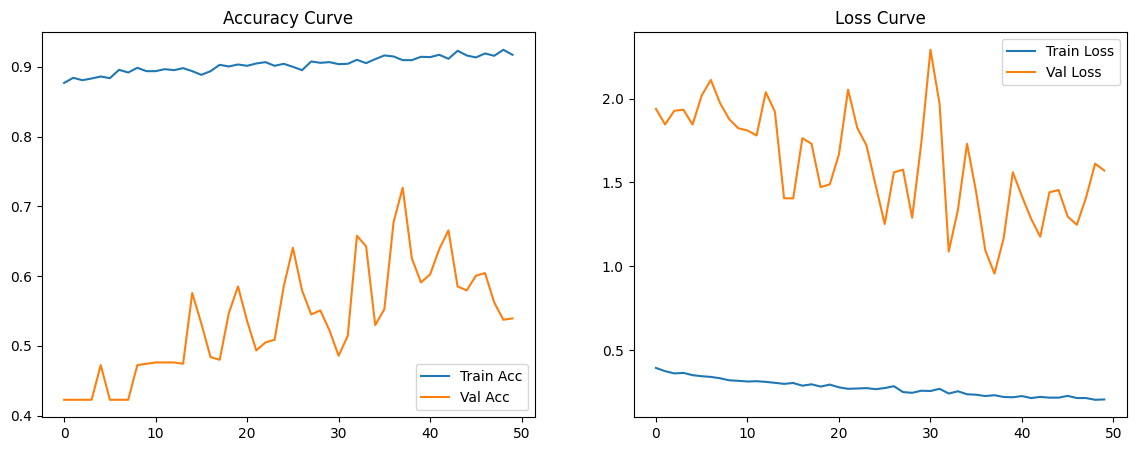

In [12]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()

# Evaluation (Accuracy, Precision, Recall, F1, Class Metrics)

In [13]:
y_pred_proba = model.predict(X_val)
y_pred = np.argmax(y_pred_proba, axis=1)

metrics = {
    "accuracy": accuracy_score(y_val, y_pred),
    "precision_macro": precision_score(y_val, y_pred, average='macro', zero_division=0),
    "recall_macro": recall_score(y_val, y_pred, average='macro', zero_division=0),
    "f1_macro": f1_score(y_val, y_pred, average='macro', zero_division=0),
    "precision_weighted": precision_score(y_val, y_pred, average='weighted', zero_division=0),
    "recall_weighted": recall_score(y_val, y_pred, average='weighted', zero_division=0),
    "f1_weighted": f1_score(y_val, y_pred, average='weighted', zero_division=0),
}

metrics

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


{'accuracy': 0.5391969407265774,
 'precision_macro': 0.413687552213868,
 'recall_macro': 0.3929253729141426,
 'f1_macro': 0.3406679536810776,
 'precision_weighted': 0.6835958091532208,
 'recall_weighted': 0.5391969407265774,
 'f1_weighted': 0.47983923163549813}

# Classification Report

In [14]:
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.21      0.35       210
           1       0.00      0.00      0.00        12
           2       0.55      0.96      0.70        98
           3       0.05      0.17      0.08        12
           4       0.00      0.00      0.00        24
           5       0.79      0.48      0.60        31
           6       0.50      0.93      0.65       136

    accuracy                           0.54       523
   macro avg       0.41      0.39      0.34       523
weighted avg       0.68      0.54      0.48       523



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrix

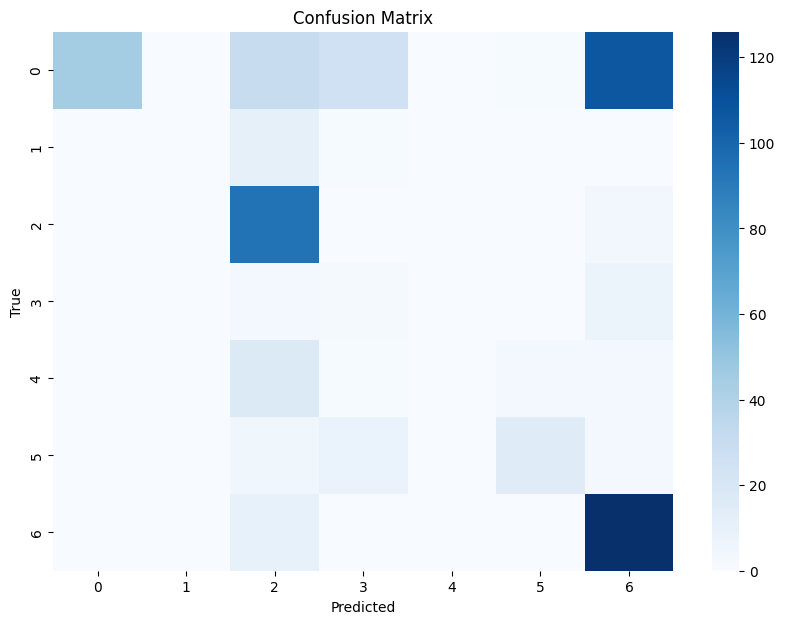

In [15]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Multi-class ROC-AUC Score

In [16]:
try:
    roc_auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_val, num_classes),
        y_pred_proba,
        multi_class="ovr"
    )
    print("ROC-AUC (multi-class):", roc_auc)
except:
    print("ROC-AUC could not be computed due to class constraints.")

ROC-AUC (multi-class): 0.9029630658472397


# Save Model + All Artifacts

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_FOLDER = f"{MODEL_SAVE_DIR}/{DATASET_NAME}_client_{CLIENT_ID}_{timestamp}"
os.makedirs(MODEL_FOLDER, exist_ok=True)

# Save model
model.save(f"{MODEL_FOLDER}/cnn_bilstm_model.h5")

# Save metrics
with open(f"{MODEL_FOLDER}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# Save predictions
np.save(f"{MODEL_FOLDER}/y_val.npy", y_val)
np.save(f"{MODEL_FOLDER}/y_pred.npy", y_pred)
np.save(f"{MODEL_FOLDER}/y_pred_proba.npy", y_pred_proba)

print("Saved to:", MODEL_FOLDER)

# Save DOCX Summary Report

In [ ]:
doc = Document()
doc.add_heading("Local CNN+BiLSTM Training Summary", level=1)

doc.add_paragraph(f"Dataset: {DATASET_NAME}")
doc.add_paragraph(f"Client ID: {CLIENT_ID}")
doc.add_paragraph(f"Timestamp: {timestamp}")
doc.add_paragraph(f"Num Classes: {num_classes}")

doc.add_heading("Performance Metrics", level=2)
for k,v in metrics.items():
    doc.add_paragraph(f"{k}: {v}")

doc.add_heading("Classification Report", level=2)
doc.add_paragraph(classification_report(y_val, y_pred))

doc_path = f"{MODEL_FOLDER}/training_summary.docx"
doc.save(doc_path)

print("DOCX saved to:", doc_path)